# Set up
**Import libraries**

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from knmy import knmy
import pandas as pd
from io import StringIO
import re

**Load and merge datasets**

In [2]:

df = pd.read_csv("../data/bunny.csv", dtype={'Oryctolagus cuniculus': str})
habitat = pd.read_csv("../data/habitats.csv")

# Merge habitats with bunny data with only matching decimalLatitude and decimalLongitude values
df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

---

## 1. Business Understanding

**Business Objective** 

* The objective of this project is to develop a predictive model for observations of Oryctolagus cuniculus using environmental and temporal factors such as habitat type, seasonality, temperature, precipitation, and geographic location.
The model aims to predict where and when rabbit observations are most likely to occur, helping improve biodiversity monitoring, ecological research, and wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
    * Achieves at least 75% prediction accuracy on unseen observation data
    * Correctly identifies seasonal and habitat-related patterns in rabbit observations
    * Maintains stable performance across different geographic regions and weather conditions

**Data Mining Goals**

* Develop a classification model that predicts the likelihood of observing Oryctolagus cuniculus using environmental variables such as habitat type, seasonality, temperature, precipitation, and geographic location.

**Data Mining Success Criteria**

* Our model should achieve at least:
75% accuracy in predicting observations of Oryctolagus cuniculus
70% precision when identifying locations and time periods with rabbit observations
75% recall in detecting actual rabbit observation occurrences based on habitat, seasonal, and weather-related variables
The model should also maintain stable predictive performance across different regions and seasons.

---

## 2. Data understanding / preparation
**Data exploration**


In [3]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
1,50.75,5.65,2010-01-02,26.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
2,50.75,5.65,2010-01-03,3.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Oryctolagus cuniculus      str    
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: float64(11), int64(1), str(3)
memory usage: 1.4 GB


In [5]:
df.describe()

,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,1.255879e+07,1.255879e+07,1.255878e+07,1.255879e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07
mean,5.222995e+01,5.532896e+00,8.136004e+00,2.212651e-01,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,1.501486e+00,1.881532e-01,1.245543e+00,2.249716e-01
std,6.647267e-01,8.779710e-01,6.264853e+01,2.511784e+00,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,1.167872e+00,7.709894e-01,2.688194e+00,7.063523e-01
min,3.500000e+00,3.350000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,7.249000e-01,0.000000e+00,9.900000e-02,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,1.199800e+00,0.000000e+00,3.102000e-01,1.820000e-02
75%,5.280000e+01,6.200000e+00,6.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,2.006500e+00,2.340000e-02,1.033000e+00,1.417000e-01
max,5.350000e+01,5.340000e+01,1.000400e+05,1.637000e+03,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,1.039830e+01,1.034430e+01,1.890870e+01,1.422410e+01


In [6]:
# Remove rows where total_observations is exactly 0
df = df[df['total_observations'] != 0]

# Optional: Check how many rows were removed
print(f"Remaining rows after filtering: {len(df)}")

Remaining rows after filtering: 6536005


**Check data distribution**

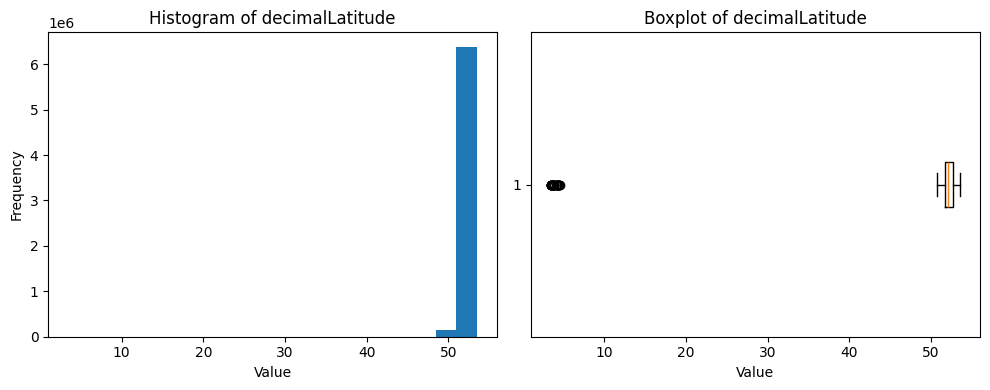

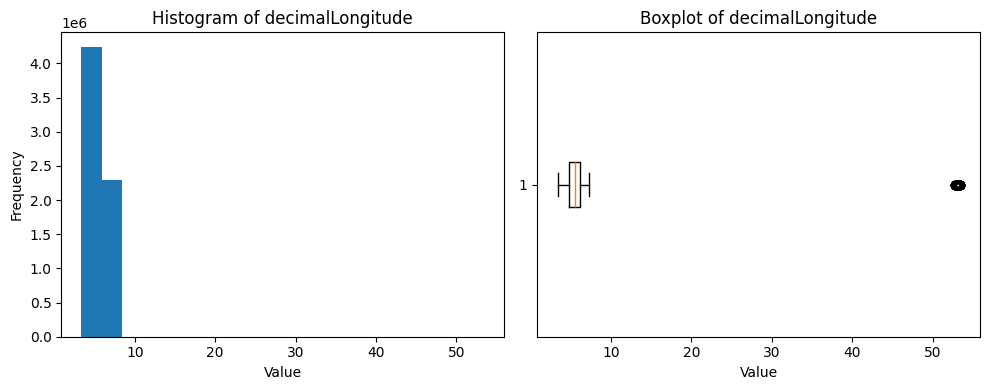

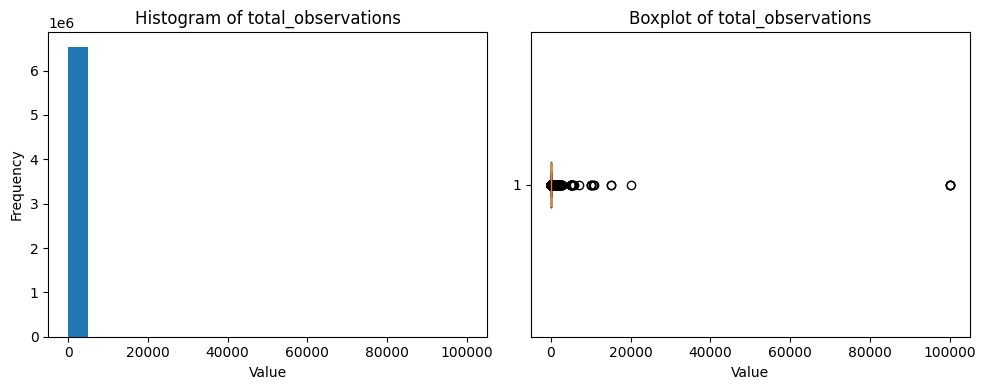

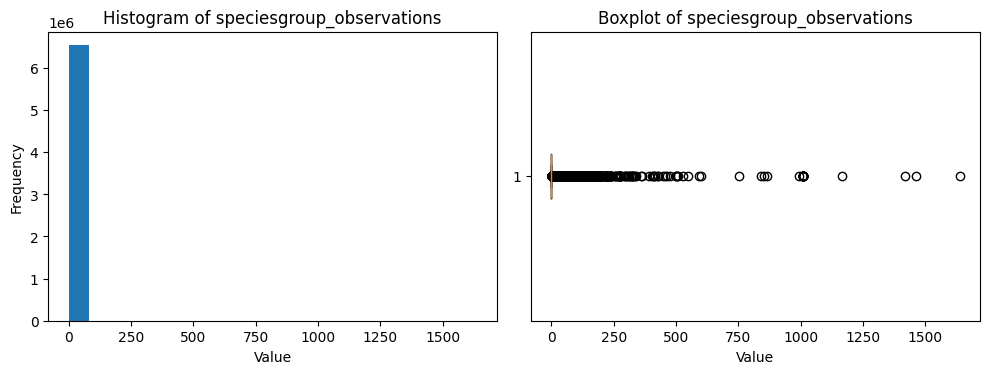

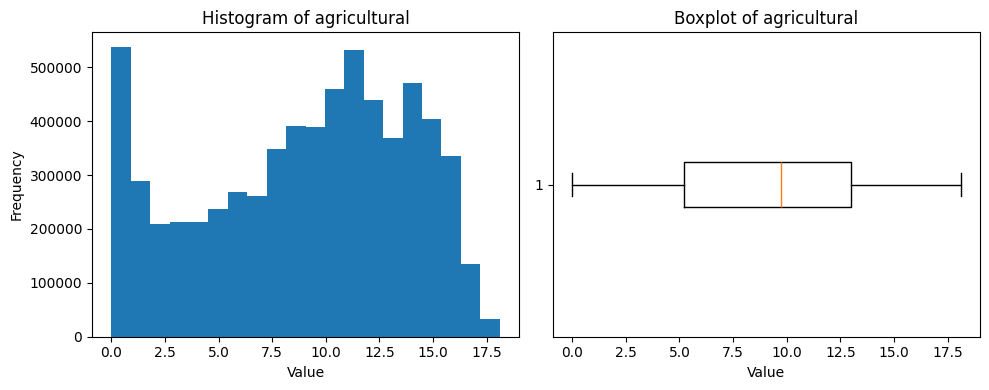

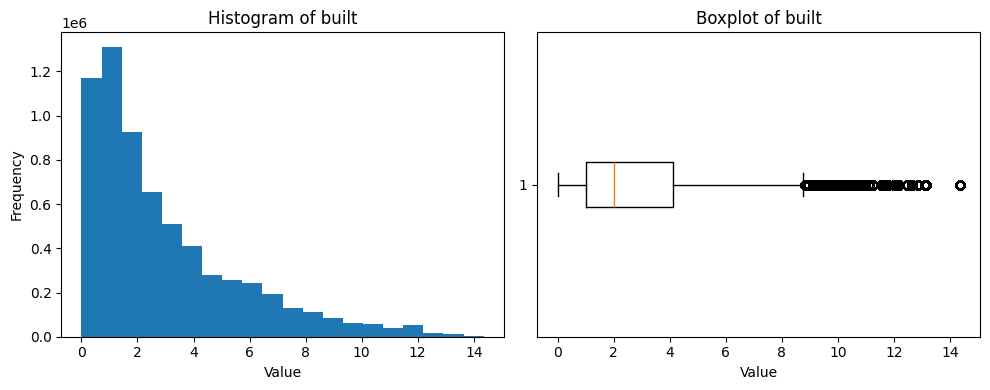

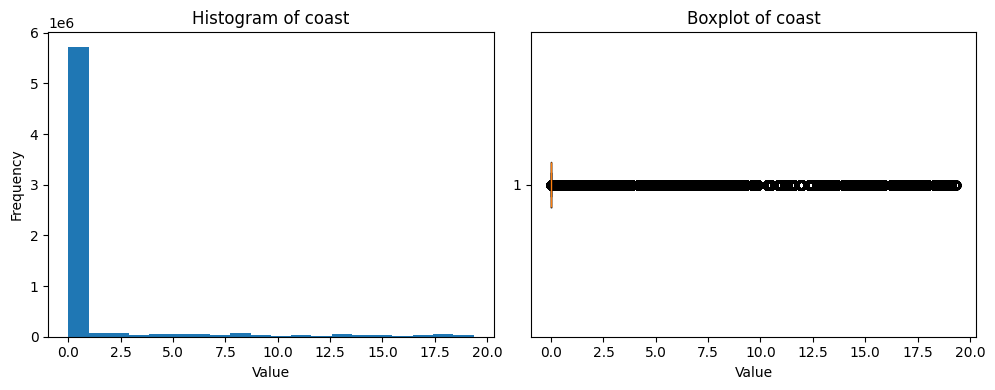

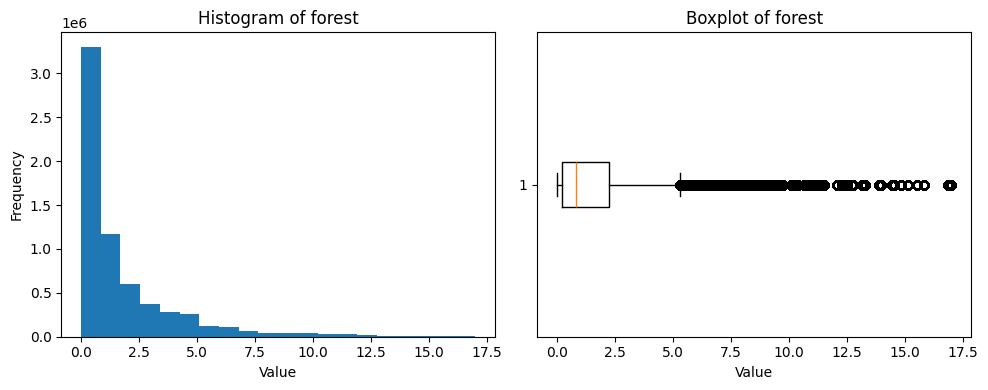

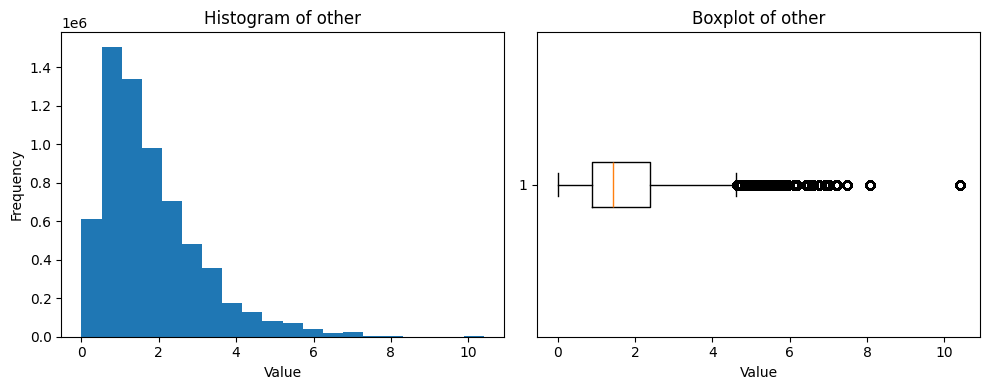

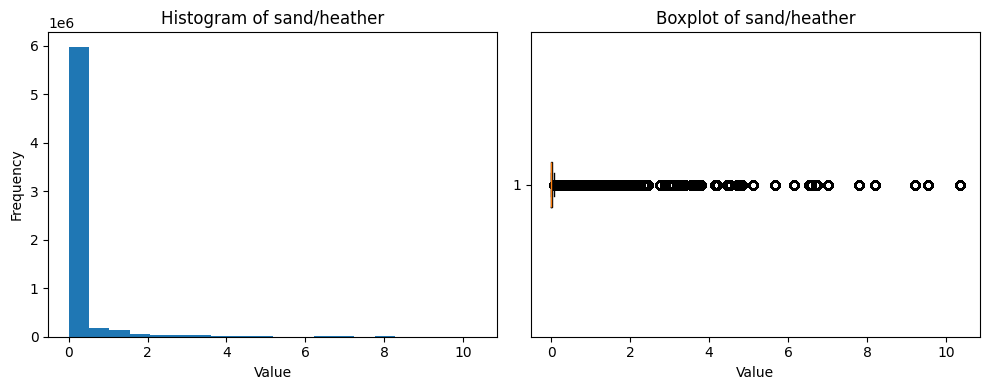

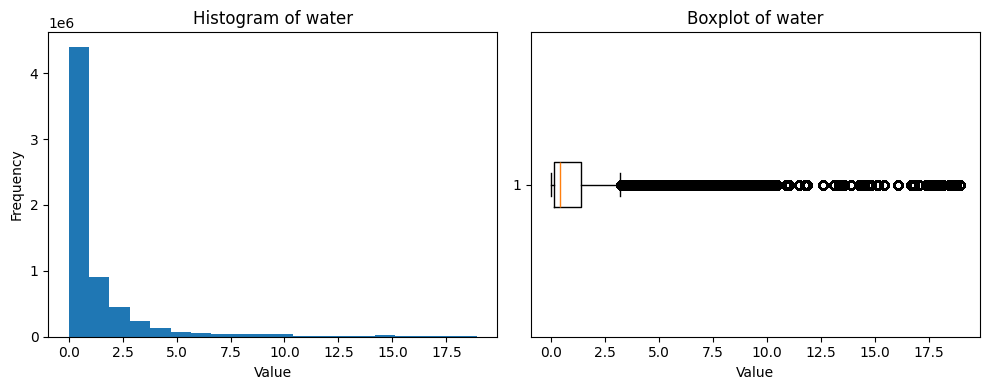

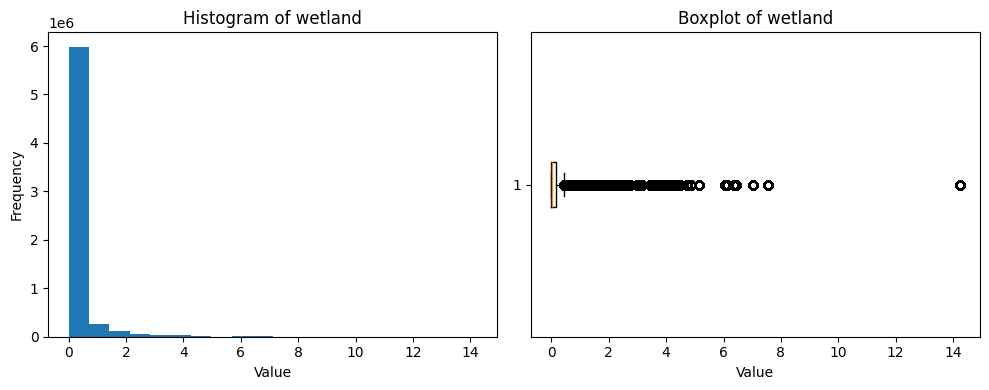

In [7]:
for col in df.describe().columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram
    axes[0].hist(df[col].dropna(), bins=20)
    axes[0].set_title(f"Histogram of {col}")
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Frequency")

    # Boxplot
    axes[1].boxplot(df[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel("Value")

    plt.tight_layout()
    plt.show()

*The histograms and boxplots for total_observations and speciesgroup_observations show that the most common value is zero. Due to the large number of zero values, the distributions are heavily right-skewed, causing even small positive values (greater than 1) to be identified as outliers in the boxplots. Therefore, the detected outliers do not necessarily represent errors or abnormal observations, but rather reflect the strong imbalance between zero and non-zero counts in the data.*

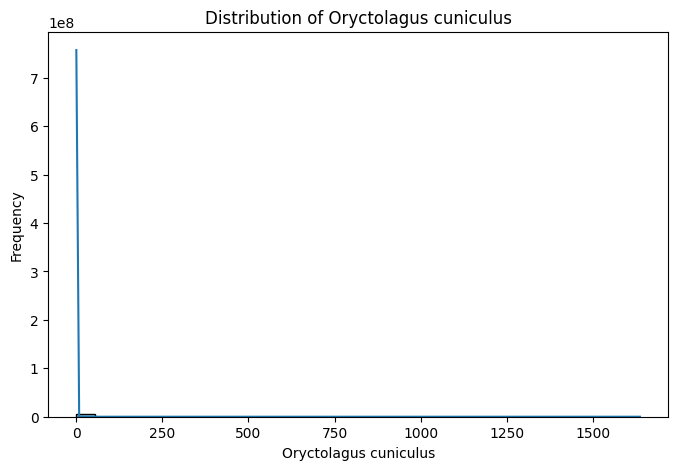

In [8]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)
plt.figure(figsize=(8,5))
sns.histplot(df["speciesgroup_observations"], bins=30, kde=True)

plt.title("Distribution of Oryctolagus cuniculus")
plt.xlabel("Oryctolagus cuniculus")
plt.ylabel("Frequency")

plt.show()

**Feature engineering**

*We added a boolean feature is_spotted from speciesgroup_observation because the business goal is to predict whether rabbits are likely to be observed at a location, not how many rabbits were seen. By simplifying the target to True (spotted) or False (not spotted), the model focuses on occurrence probability rather than observation counts.*

In [9]:
df["is_spotted"] = df["speciesgroup_observations"] > 0
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat,is_spotted
1,50.75,5.65,2010-01-02,26.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,False
2,50.75,5.65,2010-01-03,3.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,False
5,50.75,5.65,2010-01-06,1.0,1,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,True
7,50.75,5.65,2010-01-08,1.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,False
12,50.75,5.65,2010-01-13,18.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural,False


**Check duplicates, missing values or typos**

In [10]:
df.isnull().sum()

decimalLatitude               0
decimalLongitude              0
eventDate                     0
total_observations            3
speciesgroup_observations     0
Oryctolagus cuniculus         0
agricultural                 30
built                        30
coast                        30
forest                       30
other                        30
sand/heather                 30
water                        30
wetland                      30
main_habitat                 30
is_spotted                    0
dtype: int64

* *We removed all the zero values because when we took a closer look all the values were extreme and not similar at all to the rest of the data*

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(habitat["main_habitat"].unique())

<StringArray>
['agricultural',        'built',        'other',        'water',
       'forest',        'coast', 'sand/heather',      'wetland',
         'dirt']
Length: 9, dtype: str


In [13]:
df["eventDate"] = pd.to_datetime(df["eventDate"]).dt.normalize()

start_date = df["eventDate"].min().strftime("%Y%m%d")
end_date   = df["eventDate"].max().strftime("%Y%m%d")

weather_raw = knmy.get_knmi_data(
    type="daily",
    stations=[260],
    start=start_date,
    end=end_date
)

# KNMI data starts with a header after the '#' comments. 
# We skip the comments and treat it as a standard CSV.
# We use skipinitialspace=True to handle the alignment spaces.
weather_df = pd.read_csv(
    StringIO(weather_raw), 
    comment='#', 
    skipinitialspace=True,
    header=None
)

# Mapping based on standard KNMI daily index:
# 0: STN, 1: YYYYMMDD, 11: TG, 18: SQ, 22: RH
weather_df = weather_df.rename(columns={
    0: "STN",
    1: "YYYYMMDD",
    11: "TG",
    18: "SQ",
    22: "RH"
})

# Ensure YYYYMMDD is treated as a string before date conversion
weather_df["YYYYMMDD"] = weather_df["YYYYMMDD"].astype(str)

weather_df["eventDate"] = pd.to_datetime(
    weather_df["YYYYMMDD"], 
    format="%Y%m%d", 
    errors="coerce"
).dt.normalize()

# KNMI values are in 0.1 units (e.g., 115 = 11.5°C)
weather_df["temp_mean"] = pd.to_numeric(weather_df["TG"], errors="coerce") / 10
weather_df["precip_sum"] = pd.to_numeric(weather_df["RH"], errors="coerce") / 10
weather_df["sunshine_duration"] = pd.to_numeric(weather_df["SQ"], errors="coerce") / 10


weather_df = weather_df.dropna(subset=["eventDate"])


df["eventDate"] = df["eventDate"].dt.normalize()
weather_df["eventDate"] = weather_df["eventDate"].dt.normalize()

df = df.merge(
    weather_df[[
        "eventDate",
        "temp_mean",
        "precip_sum",
        "sunshine_duration"
    ]],
    on="eventDate",
    how="left"
)

df["is_weekend"] = df["eventDate"].dt.weekday.isin([5, 6]).astype(int)
df["day_of_year"] = df["eventDate"].dt.dayofyear

print("✔ Shape:", df.shape)
print(df.head())

✔ Shape: (6536005, 21)
   decimalLatitude  decimalLongitude  eventDate  total_observations  \
0            50.75              5.65 2010-01-02                26.0   
1            50.75              5.65 2010-01-03                 3.0   
2            50.75              5.65 2010-01-06                 1.0   
3            50.75              5.65 2010-01-08                 1.0   
4            50.75              5.65 2010-01-13                18.0   

   speciesgroup_observations Oryctolagus cuniculus  agricultural   built  \
0                          0                     0        1.7747  0.0568   
1                          0                     0        1.7747  0.0568   
2                          1                     0        1.7747  0.0568   
3                          0                     0        1.7747  0.0568   
4                          0                     0        1.7747  0.0568   

   coast  forest  ...  sand/heather   water  wetland  main_habitat is_spotted  \
0    0.0  0.

**Check heatmap correlation**

In [ ]:
# -----------------------------
# 1. Select relevant columns
# -----------------------------
cols = [
    'Oryctolagus cuniculus', 
    'agricultural', 'built', 'coast', 'forest',
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration',
    'is_weekend', 'day_of_year'
]

# -----------------------------
# 2. Clean data (important)
# -----------------------------
df_clean = df[cols].replace("unknown", pd.NA)

# convert everything to numeric safely
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

# drop rows with missing values
df_clean = df_clean.dropna()

# -----------------------------
# 3. Correlation matrix
# -----------------------------
corr = df_clean.corr()

# extract correlation with target species
target_corr = corr[['Oryctolagus cuniculus']].sort_values(
    by='Oryctolagus cuniculus',
    ascending=False
)

# -----------------------------
# 4. Plot heatmap
# -----------------------------
plt.figure(figsize=(8, 10))

sns.heatmap(
    target_corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)

plt.title("Correlation with Oryctolagus cuniculus")
plt.tight_layout()
plt.show()

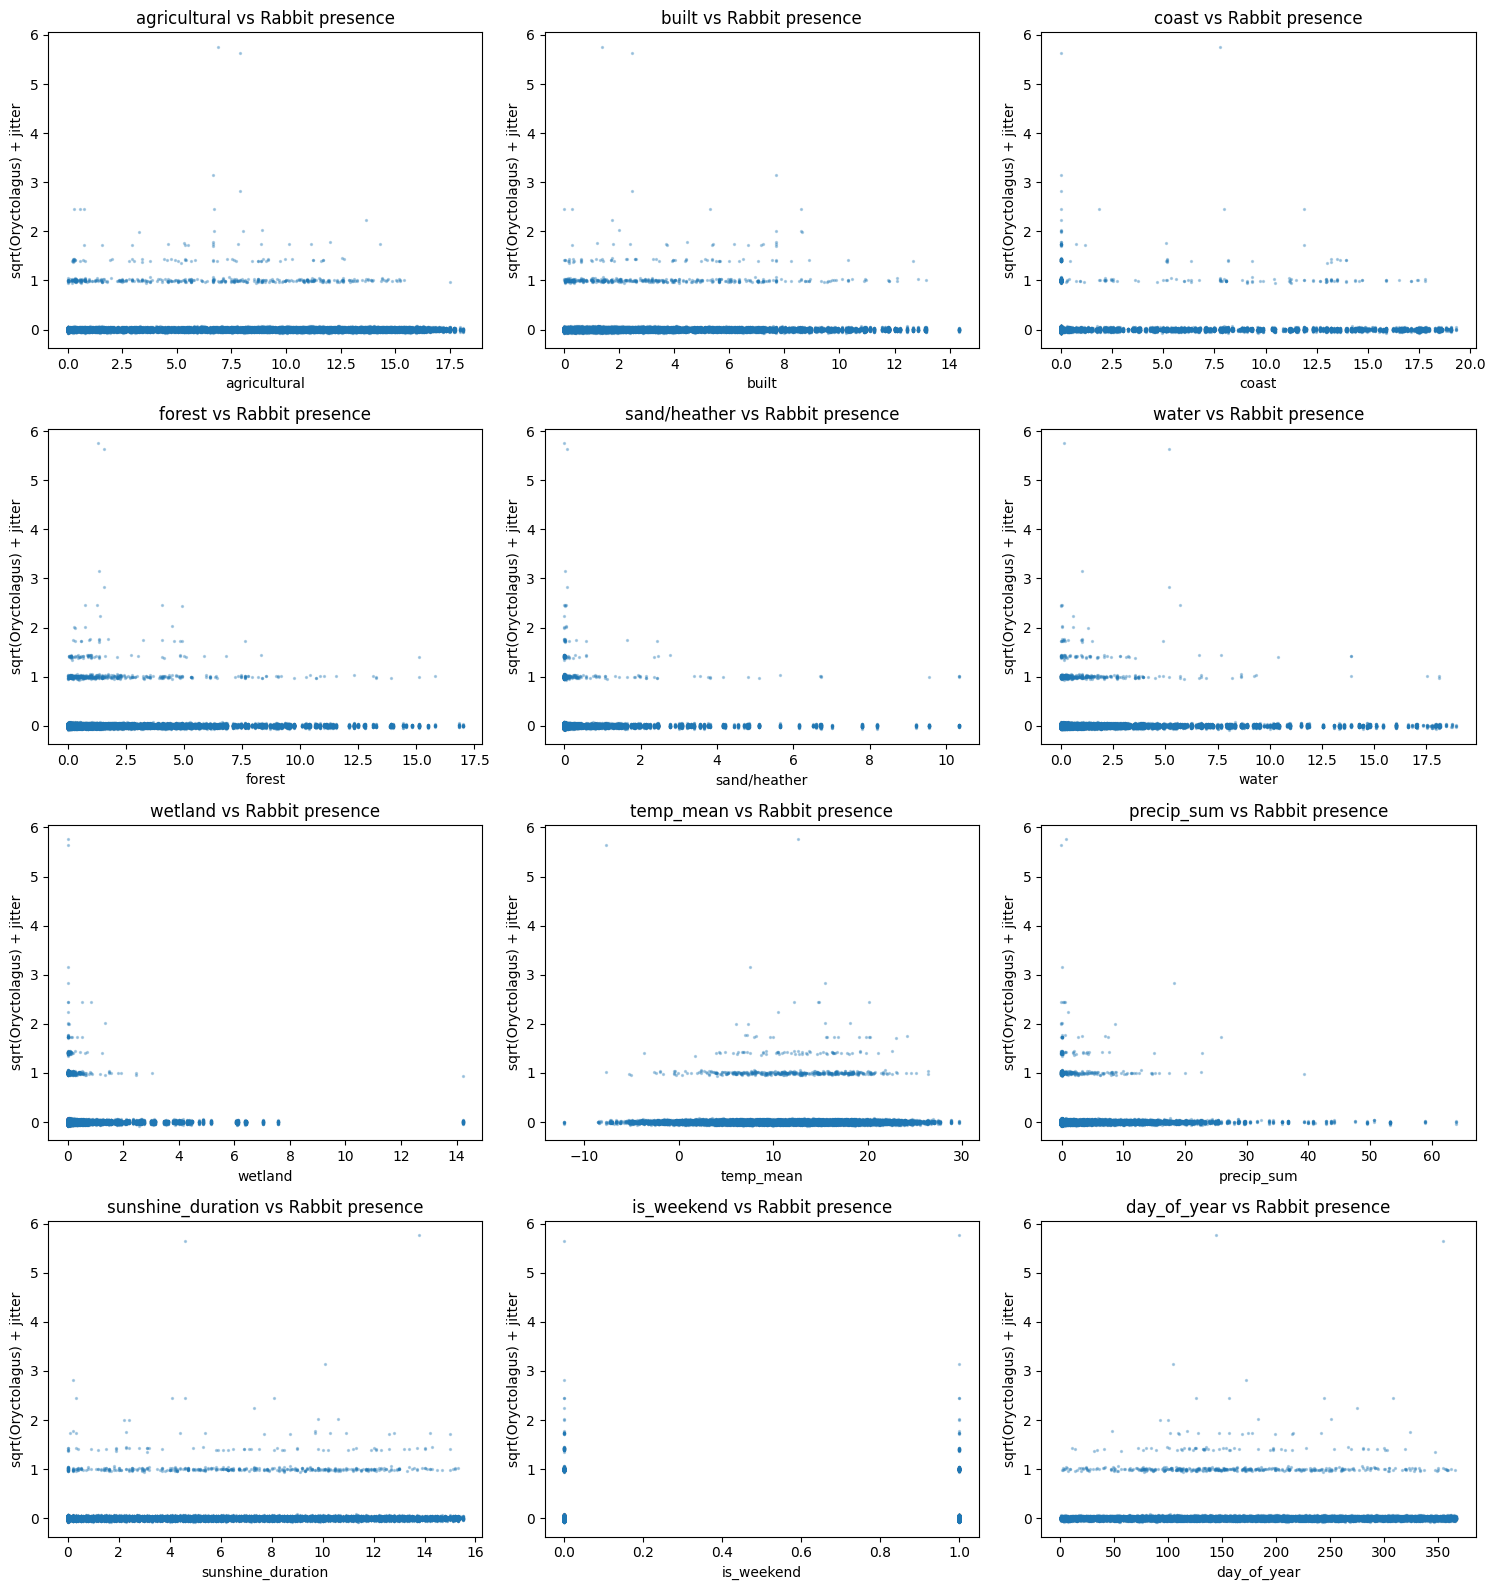

In [ ]:
features = [
    'agricultural', 'built', 'coast', 'forest',
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration',
    'is_weekend', 'day_of_year'
]

target = 'Oryctolagus cuniculus'

# -----------------------------
# 1. Clean + sample (VERY IMPORTANT)
# -----------------------------
df_plot = df[[target] + features].replace("unknown", pd.NA)
df_plot = df_plot.apply(pd.to_numeric, errors='coerce').dropna()

df_plot = df_plot.sample(50000, random_state=42)

# -----------------------------
# 2. transform target (fix flat line issue)
# -----------------------------
df_plot[target] = np.sqrt(df_plot[target])

# add jitter to reveal overlap
df_plot[target] += np.random.normal(0, 0.02, size=len(df_plot))

# -----------------------------
# 3. scatter plots
# -----------------------------
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)

    plt.scatter(
        df_plot[col],
        df_plot[target],
        alpha=0.3,
        s=2
    )

    plt.xlabel(col)
    plt.ylabel("sqrt(Oryctolagus) + jitter")
    plt.title(f"{col} vs Rabbit presence")

plt.tight_layout()
plt.show()

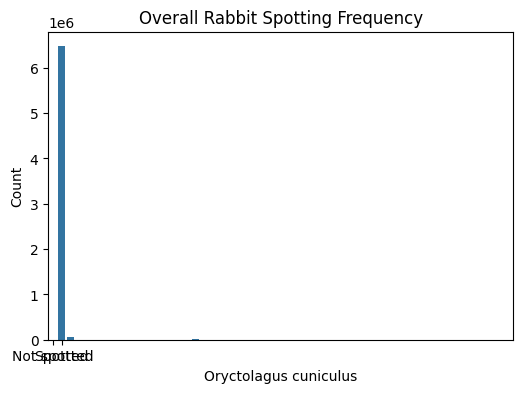

In [ ]:
counts = df["Oryctolagus cuniculus"].value_counts().sort_index()

plt.figure(figsize=(6,4))

sns.barplot(
    x=counts.index,
    y=counts.values
)

plt.xticks([0,1], ["Not spotted", "Spotted"])
plt.ylabel("Count")
plt.title("Overall Rabbit Spotting Frequency")

plt.show()

### Findings
* There is a moderate positive correlation between latitude and longitude (~0.45).
* Bunny observations (total and species group) show weak correlations with habitat types, meaning no strong habitat preference is directly visible from this analysis.
* Some habitat types are related to each other:
    * Built and ‘other’ are highly positively correlated (~0.78–0.82).
    * Forest and sand/heather show a strong positive relationship (~0.58–0.67).
    * Agricultural and coast show a negative correlation (~-0.39 to -0.46).
    * Coast and forest are negatively correlated (~-0.17 to -0.36).

In conclusion, bunnies do not strongly correlate with any specific habitat in this dataset.

In [ ]:
print(df["main_habitat"].value_counts(dropna=False))

main_habitat
agricultural    4612721
built            747517
coast            498781
forest           353056
water            265352
other             27431
sand/heather      17882
wetland           13235
NaN                  30
Name: count, dtype: int64


### Findings
* From the results above, we can conclude that most bunnies are found in agricultural areas. The second most common habitats are coastal and built environments.